In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
import datetime
from datetime import timedelta
import random
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from numba import njit
import numba as nb
from scipy.stats import zscore
import statsmodels.api as sm
import torch
import torch.nn as nn
import torch.nn.functional as F 
from scipy.stats import spearmanr
import joblib
import websocket
import json
import warnings
warnings.filterwarnings('ignore')
import sys
import time
import traceback



In [2]:
#defining hold pos for target function
hold_pos = 10


In [3]:
#Loading data
data =  pd.read_csv(r'eth_2026_up.csv')


#Calculating AVG
data['Avg'] = (data['Open']+data['Low']+data['High']+data['Close'])/4
data = data[['Open', 'High','Low','Close','Volume','datetime','Avg']]

data = data.dropna()
data['Log'] = np.log(data['Avg'])
data

,Open,High,Low,Close,Volume,datetime,Avg,Log
0,2450.38,2451.21,2446.07,2446.13,2820.517,2026-02-01 00:00:00,2448.4475,7.803209
1,2446.12,2446.84,2444.26,2446.24,2621.399,2026-02-01 00:01:00,2445.8650,7.802154
2,2446.24,2455.69,2445.83,2455.42,2888.893,2026-02-01 00:02:00,2450.7950,7.804168
3,2455.41,2458.37,2452.76,2454.23,6589.965,2026-02-01 00:03:00,2455.1925,7.805960
4,2454.23,2455.16,2451.60,2452.49,2427.853,2026-02-01 00:04:00,2453.3700,7.805218
...,...,...,...,...,...,...,...,...
305275,2465.76,2465.77,2465.04,2465.40,525.214,2026-08-31 23:55:00,2465.4925,7.810147
305276,2465.40,2465.40,2464.71,2465.33,529.030,2026-08-31 23:56:00,2465.2100,7.810032
305277,2465.34,2466.50,2465.34,2466.01,329.737,2026-08-31 23:57:00,2465.7975,7.810271
305278,2466.01,2466.01,2466.00,2466.01,150.804,2026-08-31 23:58:00,2466.0075,7.810356


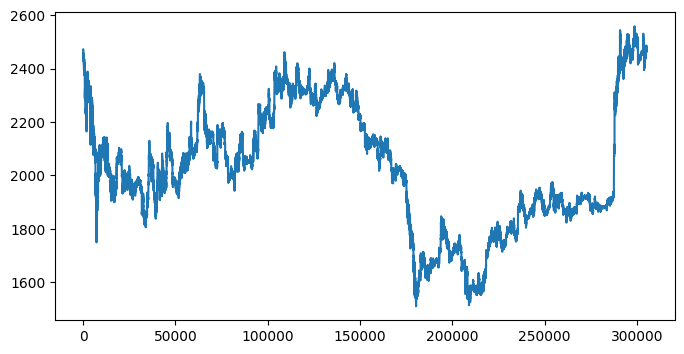

In [4]:
plt.figure(figsize=(8,4))
plt.plot(data['Avg'])

In [5]:
@njit
def run_rolling_nis_dynamic_numba(log_prices, periods, q_lookback, Q_scale=0.1, R_scale=1.0):
    n = len(log_prices)
    sum_nis_output = np.empty(n, dtype=np.float64)
    sum_nis_output[:] = np.nan
    n2 = periods - 1

    # Ensure enough history exists for both q_lookback and the test window
    start_idx = max(n2, q_lookback)

    # Outer Loop: Slides the test window over time
    for i in range(start_idx, n):
        window_start = i - n2
        
        # 1. DYNAMIC CALCULATION: Extract history strictly prior to the current window
        # E.g., if q_lookback=120, look at the past 120 returns to calibrate the current step
        hist_start = window_start - q_lookback
        if hist_start < 0:
            hist_start = 0
            
        # --- OPTIMIZED VARIANCE CALCULATION (ZERO ALOCATION) ---
        hist_len = window_start - hist_start  # Number of returns
        
        if hist_len > 0:
            # 1st Pass: Calculate the mean of returns
            sum_ret = 0.0
            for idx in range(hist_start, window_start):
                sum_ret += (log_prices[idx + 1] - log_prices[idx])
            mean_ret = sum_ret / hist_len
            
            # 2nd Pass: Calculate the variance
            sum_sq_diff = 0.0
            for idx in range(hist_start, window_start):
                ret = log_prices[idx + 1] - log_prices[idx]
                diff = ret - mean_ret
                sum_sq_diff += diff * diff
            base_variance = sum_sq_diff / hist_len
        else:
            base_variance = 1e-8

        # If the market freezes, prevent division by zero
        if base_variance <= 1e-8: 
            base_variance = 1e-8

        # 2. DYNAMIC Q AND R UPDATE
        global_q = base_variance * Q_scale
        global_r = base_variance * R_scale

        # Filter initialization for the current window with updated parameters
        state_estimate = log_prices[window_start]
        P = global_r 
        window_sum_nis = 0.0

        # Inner Loop: Runs the local Kalman Filter with updated Q and R
        for j in range(1, periods):
            price_t = log_prices[window_start + j]

            # Prediction step
            pred_state = state_estimate
            pred_P = P + global_q

            # Update step
            innovation = price_t - pred_state
            S_t = pred_P + global_r

            # NIS accumulation
            nis_t = (innovation * innovation) / S_t
            window_sum_nis += nis_t

            # State update
            K_t = pred_P / S_t
            state_estimate = pred_state + K_t * innovation
            P = (1.0 - K_t) * pred_P

        sum_nis_output[i] = window_sum_nis

    return sum_nis_output

In [6]:
#def scan_dataframe_fast_dynamic(df, periods=10, q_lookback=90):
def scan_dataframe_fast_dynamic(df, periods=10, q_lookback=60):
    log_prices_arr = df['Log'].to_numpy()

    # Dynamic function (Q and R change each new line)
    sum_nis_array = run_rolling_nis_dynamic_numba(
        log_prices_arr, periods, q_lookback, Q_scale=0.01, R_scale=10.0
    )

    # Wilson-Hilferty for Chi-Squared 95%
    df_degrees = periods - 1
    z_90 = 1.2815515655446004
    z_95 = 1.6448536269514722
    z_99 = 2.326
    critical_value = df_degrees * (1.0 - 2.0 / (9.0 * df_degrees) + z_95 * np.sqrt(2.0 / (9.0 * df_degrees))) ** 3

    df['sum_nis'] = sum_nis_array
    df['is_stationary'] = sum_nis_array <= critical_value
    df['market_regime'] = np.where(
        df['sum_nis'].isna(), 'WARMUP',
        np.where(df['is_stationary'], 'STATIONARY', 'NON-STATIONARY')
    )
    
    return df

In [7]:
#HYPER PARAMETERS ON KALMAN FILTER
periods = 10
q_lookback = 60


data = scan_dataframe_fast_dynamic(data, periods, q_lookback)
stationary = len(data[data['market_regime']=='STATIONARY'])
non_stationary = len(data[data['market_regime']=='NON-STATIONARY'])       
print(stationary/(stationary+non_stationary))

0.9703132166961536


In [8]:
# Function to create factors and define targets
def dat(data, hold_pos):

    df = pd.DataFrame(data)

    
    ###############AROON ##################
    
    @njit
    def fast_aroon_osc(high, low, window):
        n = len(high)
        out = np.full(n, np.nan)

        for i in range(window - 1, n):
            # Search max and min manual window
            max_idx = 0
            min_idx = 0
            max_val = high[i - window + 1]
            min_val = low[i - window + 1]

            for j in range(1, window):
                curr_h = high[i - window + 1 + j]
                curr_l = low[i - window + 1 + j]

                if curr_h >= max_val:
                    max_val = curr_h
                    max_idx = j
                if curr_l <= min_val:
                    min_val = curr_l
                    min_idx = j

            up = ((max_idx + 1) / window) * 100
            down = ((min_idx + 1) / window) * 100
            out[i] = up - down
            
        return out

    # loop:
    high_arr = df['High'].values
    low_arr = df['Low'].values

    for i in range(15, 36, 10):
        df[f'AAR_{i}'] = fast_aroon_osc(high_arr, low_arr, i)
        
        
        
    ######################### Volume profile####################################
        
    @njit
    def fast_poc_expanding_numba(close, volume, max_window=300, min_periods=70, bins=20):
        n = len(close)
        out = np.full(n, np.nan)

        # Start calculation after reaching min period (70)
        for i in range(min_periods - 1, n):
            # Expansive window logic
            # If i < 300, window is [0 : i+1] (size i+1)
            # If i >= 300, window is [i-299 : i+1] (fixed size 300)
            start = max(0, i - max_window + 1)

            w_close = close[start : i + 1]
            w_vol = volume[start : i + 1]

            p_min = np.min(w_close)
            p_max = np.max(w_close)

            if p_min >= p_max:
                out[i] = 0.0
                continue

            # Histogram manual 
            hist = np.zeros(bins)
            bin_width = (p_max - p_min) / bins

            for j in range(len(w_close)):
                # Calculateo bin 
                val = w_close[j]
                idx = int((val - p_min) / bin_width)
                if idx >= bins: 
                    idx = bins - 1 # Garante que o valor máximo entre no último bin
                hist[idx] += w_vol[j]

            # Find bin with higher volume (Point of Control)
            max_bin_idx = np.argmax(hist)
            poc = p_min + (max_bin_idx + 0.5) * bin_width

            # p_last / poc - 1 
            out[i] = close[i] / poc - 1

        return out

    # Final
    df['Vpro'] = fast_poc_expanding_numba(
        df['Close'].values, 
        df['Volume'].values, 
        max_window=300, 
        min_periods=70
    )
    
     ############## VWAP #################
   
    @njit
    def fast_vwap_zscore(close, high, low, volume, max_window=300, min_periods=30):
        n = len(close)
        vwap_z = np.full(n, np.nan)

        # Tipical price weighted by volume
        tp_vol = ((close + high + low) / 3.0) * volume

        for i in range(min_periods - 1, n):
            # Define the start of the expansive window (expansive up to max_window)
            start = max(0, i - max_window + 1)

            # VWAP
            sum_tp_vol = np.sum(tp_vol[start : i + 1])
            sum_vol = np.sum(volume[start : i + 1])

            if sum_vol == 0:
                vwap_z[i] = 0.0
                continue

            current_vwap = sum_tp_vol / sum_vol

            #  Z-Score (df['Close'] - vwap) / std(vwap)
            if i >= start + min_periods:
                # Calculate STD for the VWAP values in the window
                # for performance, rxtract histórical VWAPs 
                window_vwaps = np.zeros(i - start + 1)
                temp_tp_vol = 0.0
                temp_vol = 0.0

                # sub-loop calculate historical VWAPs for STD
                for k in range(start, i + 1):
                    temp_tp_vol = np.sum(tp_vol[start : k + 1])
                    temp_vol = np.sum(volume[start : k + 1])
                    window_vwaps[k - start] = temp_tp_vol / temp_vol if temp_vol != 0 else current_vwap

                std_vwap = np.std(window_vwaps)

                if std_vwap != 0:
                    vwap_z[i] = (close[i] - current_vwap) / std_vwap
                else:
                    vwap_z[i] = 0.0

        return vwap_z
    
      # DataFrame
    df['VWAP_i'] = fast_vwap_zscore(
        df['Close'].values, df['High'].values, 
        df['Low'].values, df['Volume'].values
    )
    
    ###### Weighted MACD short term ######
        
    @nb.njit(parallel=True, cache=True)
    def calculate_vwap_numba(Close, Low, High, Volume, window, min_periods):
        """Calculates a moving 300-period VWAP using pre-allocated native arrays."""
        n = len(Close)
        vwap_base = np.empty(n)
        vwap_base[:] = np.nan

        # Pre-calculate Typical Price * Volume
        t_pr_vol = ((Close + Low + High) / 3.0) * Volume

        # Parallel window processing
        for i in nb.prange(n):
            if i < min_periods - 1:
                continue
            start = max(0, i - window + 1)

            sum_t_pr = 0.0
            sum_vol = 0.0
            for j in range(start, i + 1):
                sum_t_pr += t_pr_vol[j]
                sum_vol += Volume[j]

            if sum_vol != 0.0:
                vwap_base[i] = sum_t_pr / sum_vol

        return Close / vwap_base - 1.0

    @nb.njit(cache=True)
    def ewm_numba(arr, span):
        """Calculates Exponential Moving Average matching Pandas 'adjust=False'."""
        n = len(arr)
        out = np.empty(n, dtype=np.float64) # 🟢 FIXED: Allocates a clean, isolated array in memory
        if n == 0:
            return out

        alpha = 2.0 / (span + 1.0)

        # Safely prime the first valid element
        if n > 0:
            out[0] = arr[0]

        for i in range(1, n):
            if np.isnan(arr[i]):
                out[i] = out[i-1]
            elif np.isnan(out[i-1]):
                out[i] = arr[i]
            else:
                out[i] = arr[i] * alpha + out[i-1] * (1.0 - alpha)
        return out

    @nb.njit(cache=True)
    def rolling_mean_numba(arr, window):
        """Calculates standard Simple Moving Average (SMA)."""
        n = len(arr)
        out = np.empty(n)
        out[:] = np.nan

        if n < window:
            return out

        current_sum = 0.0
        for i in range(window):
            current_sum += arr[i]
        out[window - 1] = current_sum / window

        for i in range(window, n):
            current_sum += arr[i] - arr[i - window]
            out[i] = current_sum / window
        return out

    @nb.njit(parallel=True, cache=True)
    def process_signals_numba(Close, vwap2, n1, n2, n3):
        """Processes MACD EWM/Rolling layers and handles vectorized signal logic."""
        n = len(Close)

        # --- 1. EXPONENTIAL MACD LAYER (EWM) ---
        ma_fast_ewm = ewm_numba(Close, n1)
        ma_slow_ewm = ewm_numba(Close, n2)
        ma_ewm = ma_fast_ewm - ma_slow_ewm
        sig_ewm = ewm_numba(ma_ewm, n3)
        macds_ewm = ma_ewm - sig_ewm
        macd_out = np.zeros(n)

        # --- 2. ROLLING MACD LAYER (SMA) ---
        ma_fast_roll = rolling_mean_numba(Close, n1)
        ma_slow_roll = rolling_mean_numba(Close, n2)
        ma_roll = ma_fast_roll - ma_slow_roll
        sig_roll = ewm_numba(ma_roll, n3)
        macds_roll = ma_roll - sig_roll
        macdn_out = np.zeros(n)

        # --- 3. SIGNAL TRIGGERING AND HISTOGRAM LOGIC ---
        for t in nb.prange(1, n):
            # EWM Signals (Utilizes trend filter via vwap2)
            cross_up_ewm = (ma_ewm[t] > sig_ewm[t]) and (ma_ewm[t-1] <= sig_ewm[t-1])
            cross_down_ewm = (ma_ewm[t] < sig_ewm[t]) and (ma_ewm[t-1] >= sig_ewm[t-1])

            cond_long_ewm = (ma_ewm[t] < 0.0) and cross_up_ewm and (vwap2[t] > 0.0)
            cond_short_ewm = (ma_ewm[t] > 0.0) and cross_down_ewm and (vwap2[t] < 0.0)

            if cond_long_ewm or cond_short_ewm:
                macd_out[t] = macds_ewm[t]

            # Rolling Signals
            if np.isnan(ma_roll[t]) or np.isnan(sig_roll[t]) or np.isnan(ma_roll[t-1]) or np.isnan(sig_roll[t-1]):
                continue

            cross_up_roll = (ma_roll[t] > sig_roll[t]) and (ma_roll[t-1] <= sig_roll[t-1])
            cross_down_roll = (ma_roll[t] < sig_roll[t]) and (ma_roll[t-1] >= sig_roll[t-1])

            cond_long_roll = (ma_roll[t] < 0.0) and cross_up_roll
            cond_short_roll = (ma_roll[t] > 0.0) and cross_down_roll

            if cond_long_roll or cond_short_roll:
                macdn_out[t] = macds_roll[t]

        return macd_out, ma_ewm, macds_ewm, macdn_out

    # --- 2. MAIN INTEGRATION WRAPPER FOR PANDAS DATAFRAMES ---

    def execute_strategy_numba(df):
        """Extracts NumPy arrays from DataFrame, triggers Numba, and commits back."""
        Close = np.ascontiguousarray(df['Close'].to_numpy(dtype=np.float64))
        Low = np.ascontiguousarray(df['Low'].to_numpy(dtype=np.float64))
        High = np.ascontiguousarray(df['High'].to_numpy(dtype=np.float64))
        Volume = np.ascontiguousarray(df['Volume'].to_numpy(dtype=np.float64))

        # Step 1: Pre-calculate 300 VWAP layer outside loop
        df['vwap2'] = calculate_vwap_numba(Close, Low, High, Volume, window=300, min_periods=70)
        vwap2_arr = np.ascontiguousarray(df['vwap2'].to_numpy(dtype=np.float64))

        # Step 2: Unified loop execution
        for i in range(6, 25, 6):
            n1, n2, n3 = i, 2 * i, int(round(i / 1.5)) # 🟢 OPTIMIZED: Forces explicit int signature to ensure clean compilation

            macd_out, ma_ewm, macds_ewm, macdn_out = process_signals_numba(
                Close, vwap2_arr, n1, n2, n3
            )

            df[f'MACD_{i}'] = macd_out
            df[f'MA_{i}'] = ma_ewm
            df[f'MACDS_{i}'] = macds_ewm
            df[f'MACDN_{i}'] = macdn_out

        return df

    # Execute the strategy using your DataFrame
    df = execute_strategy_numba(df)

    ####### HEIKEN ASHI ################

    @njit # Just-In-Time compilation for max performance 
    def _calcular_ha_core_fast(op, hi, lo, cl, vw):
        n = len(op)
        ha_open = np.empty(n)
        ha_close = (op + hi + lo + cl) / 4.0

        # Firsto candle (Seed)
        ha_open[0] = (op[0] + cl[0]) / 2.0

        # Loop recursive Heikin-Ashi
        for i in range(1, n):
            ha_open[i] = (ha_open[i-1] + ha_close[i-1]) / 2.0

        ha_high = np.maximum(hi, np.maximum(ha_open, ha_close))
        ha_low = np.minimum(lo, np.minimum(ha_open, ha_close))

        sinal = np.zeros(n)

        # Starts in 1 to avoid i-1 acess index wrong way
        for i in range(1, n):
           
            if (ha_close[i] > ha_open[i]) and (ha_open[i]==ha_low[i]):
                sinal[i] = 1.0
            elif (ha_close[i] > ha_open[i]) and (ha_close[i-1] < ha_open[i]):
                sinal[i] = 1.0
            
            elif (ha_close[i] < ha_open[i]) and (ha_open[i]==ha_high[i]):
                sinal[i] = -1.0  
            elif (ha_close[i] < ha_open[i]) and (ha_close[i-1] > ha_open[i]):
                sinal[i] = -1.0
                
                
        return sinal

    @njit
    def _sequence_counter_fast(sinal):
        n = len(sinal)
        ha_count = np.zeros(n)
        current_sum = 0.0

        for i in range(n):
            if sinal[i] == 0.0:
                current_sum = 0.0
            elif i > 0 and sinal[i] != sinal[i-1]:
                current_sum = sinal[i]  # Reinicia a contagem com o novo sinal
            else:
                current_sum += sinal[i]
            ha_count[i] = current_sum
        return ha_count

    def HA(df):
        # numeric arrays (.values) numba
        sinal = _calcular_ha_core_fast(
            df['Open'].values, 
            df['High'].values, 
            df['Low'].values, 
            df['Close'].values, 
            df['vwap2'].values
        )

        df['HA_Sinal'] = sinal
        df['HA_Seq'] = _sequence_counter_fast(sinal)
        return df
    # Dataframe integration
    
    df = HA(df)

    ########CCI

    @njit
    def calcular_cci_fast(typ_price, window):
        n = len(typ_price)
        out = np.full(n, np.nan)

        for i in range(window - 1, n):
            # 1. Window typical price
            janela = typ_price[i - window + 1 : i + 1]

            # 2. Moving average typical price (TP_MA)
            tp_ma = np.mean(janela)

            # 3. Absolute STD (MAD) 
            # A fórmula is teh average de abs(typical price - avg typical price)
            mad = np.mean(np.abs(janela - tp_ma))

            # 4. CCI
            if mad != 0:
                out[i] = (typ_price[i] - tp_ma) / (0.015 * mad)
            else:
                out[i] = 0

        return out

    # Integration Loop
    tp = ((df['High'] + df['Low'] + df['Close']) / 3).values

    for i in range(5, 21, 5):
        df[f'CCI_{i}'] = calcular_cci_fast(tp, i)

    ################### ATR - volatility indicator

    @njit
    def calcular_atr_wilder(high, low, close, window):
        n = len(high)
        tr = np.zeros(n)
        atr = np.zeros(n)

        # 1. True Range (TR)
        for i in range(1, n):
            hl = high[i] - low[i]
            hc = abs(high[i] - close[i-1])
            lc = abs(low[i] - close[i-1])
            tr[i] = max(hl, max(hc, lc))
        tr[0] = high[0] - low[0] # Primeiro valor

        # 2. ATR (Wilder softness)
        # First ATR is avg first windows TRs
        sum_tr = 0.0
        for i in range(window):
            sum_tr += tr[i]
        atr[window-1] = sum_tr / window

        # Next ATRs: (ATR_previous * (n-1) + TR_atual) / n
        for i in range(window, n):
            atr[i] = (atr[i-1] * (window - 1) + tr[i]) / window

        return atr

    #  arrays
    h = df['High'].values
    l = df['Low'].values
    c = df['Close'].values

    for i in range(7, 22, 7):
        # Calculate ATR e  normalized by Close 
        atr_values = calcular_atr_wilder(h, l, c, i)
        df[f'ATR_{i}'] = atr_values / c


   ############### TGT Target
    ### Different targets for different holding periods and models.ewm(span=n1, adjust=False).mean()
    # 
    target_price = df['Avg'].shift(-hold_pos).ewm(span=int(hold_pos), adjust=False).mean()
    target_price2 = df['Avg'].ewm(span=int(hold_pos), adjust=False).mean()

    # 2. return 
    df["ret"] = (target_price.values / df['Avg'].shift(-1).values) - 1
    df["ret2"] = (target_price2.values / df['Avg'].shift(hold_pos).values) - 1

    # 3. cleaning
    del target_price
    
    
    
        
    target_price = df['Avg'].shift(-hold_pos).ewm(span=int(hold_pos), adjust=False).mean()
    df['Tgt'] = (target_price.values / df['Avg'].shift(-1).values) - 1
    # Define a historical lookback window (e.g., 500 or 1000 rows)
    z_lookback = 500  

    # Calculate rolling statistical baselines based ONLY on past data
    rolling_mean = df['Tgt'].rolling(window=z_lookback, min_periods=30).mean()
    rolling_std = df['Tgt'].rolling(window=z_lookback, min_periods=30).std()
    df["Mean"] = rolling_mean
    df["Std"] = rolling_std

    # Apply the Z-score transformation: (X - Mean) / Std
    # We add a tiny epsilon (1e-8) to prevent zero-division errors if volatility crushes to 0
    df['Tgt'] = (df['Tgt'] - rolling_mean) / (rolling_std + 1e-8)

    # Trig will be used to create stop loss and stp profits
    df['Trig'] = df['ret2'].abs().rolling(5).mean()         
        
        
    

    ###########RSI 15
    df['S1_pct'] = df['Close'].pct_change()

    @njit
    def calcular_rsi_wilder(changes, window):
        n = len(changes)
        rsi = np.full(n, np.nan)

        # separate profit losses (Vetorized on Numba)
        gains = np.where(changes > 0, changes, 0.0)
        losses = np.where(changes < 0, -changes, 0.0)

        # Initialization (simple avg for first value)
        avg_gain = np.mean(gains[:window])
        avg_loss = np.mean(losses[:window])

        if avg_loss == 0:
            rsi[window-1] = 100
        else:
            rs = avg_gain / (avg_loss + 1e-10)
            rsi[window-1] = 100 - (100 / (1 + rs))

        # Wilder softness (Recursive)
        for i in range(window, n):
            avg_gain = (avg_gain * (window - 1) + gains[i]) / window
            avg_loss = (avg_loss * (window - 1) + losses[i]) / window

            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / (avg_loss + 1e-10)
                rsi[i] = 100 - (100 / (1 + rs))

        return rsi - 50 #  centralized on 0 

    # Integration Loop
    # S1_pct é a percentual change on Close
    changes = df['S1_pct'].values

    for i in range(10, 31, 10):
        df[f'RSI_{i}'] = calcular_rsi_wilder(changes, i)

    
        
        
    df = df.dropna()
    df = df.reset_index(drop=True)




    return df

In [9]:
def remove_outliers_zscore(data, column, threshold=3):
    df1 = data[column]
    data['z_score'] = np.abs(zscore(data[column]))
    filtered_data = data[data['z_score'] <= threshold].drop('z_score', axis=1)
    return filtered_data


df = dat(data,hold_pos)



In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
# Delete rows containing any NaN values
df.dropna(inplace=True)

In [11]:
# Function to define test and train datasets.
#The model was trained between 2024/1/1 to 2025/12/31


def train_test(df):

    #Define test dates
    #test_dep = datetime.datetime(2026,4,1)
    test_dep = datetime.datetime(2026,1,1)
    test_dep_max = datetime.datetime(2026,6,30)
        
    df['datetime'] =  pd.to_datetime(df['datetime'], format='mixed')

    #data filetr
    df_test = df[(df['datetime'] >= test_dep) & (df['datetime'] <= test_dep_max)]

        
    #Stationary FLOAT
    df_test['M_R'] = df_test['market_regime'].apply(lambda x: 1 if x== "NON-STATIONARY" else 0)
    
    df_test.replace(-np.inf, np.nan)
    df_test = df_test.dropna()
    
    #indicators
    

    X_test =  df_test[[#'MACD_6',
                       #'MACD_12',
                       #'MACD_18',
                       #'MACD_24',
                        #'MACD_6',
                       'MA_12',############
                       #'MA_18',
                       'MA_24',##############
                       #'MACDN_6',
                       #'MACDS_12',
                       #'MACDS_18',
                       #'MACDS_24',
                         'ATR_7',#############
                       #'ATR_14',
                        #'ATR_21',
                       'VWAP_i',##############
                       #'RSI_10',###################
                        #'RSI_20',
                        #'RSI_30',
                        #'CCI_5',
                        'CCI_10',#############
                        #'CCI_15',
                        #'CCI_20',
                        'AAR_15',##################
                        #'AAR_25',
                        #'AAR_35',
                        #'Vpro',
                        'HA_Sinal',
                        #'HA_Seq',
                        #'sum_nis'################
                        ]]
    

    

    # Correlation Matrix
    #corr_matrix = X_test.corr()
    
    y_test = df_test['Tgt']
    
    return df_test, X_test, y_test

In [12]:
df_test, X_test, y_test_sc = train_test(df)


In [13]:
#scaling

#Loading scaler
my_production_scaler = joblib.load('my_production_scaler_ETH_reg.pkl')
X_test_sc = my_production_scaler.transform(X_test)

#print(X_test_sc.size)

#X_test_sc = pd.DataFrame(X_test_sc)

#my_production_scaler2 = joblib.load('my_production_scaler_ETH_reg2.pkl')
#y_test_sc = my_production_scaler2.transform(y_test.to_frame())

#X_test_sc = pd.DataFrame(X_test_sc)


In [14]:
#Not using PCA transformation in this model but leaving the possibility if needed
X_test_sc_pca = X_test_sc

In [15]:
load_path = 'modelETHNumbaKFSwiGLU.pth'
state_dict = torch.load(load_path, weights_only=True)

# Print out the exact shapes of your trained layers
for key, value in state_dict.items():
    print(f"{key}: {list(value.shape)}")
    
    

bn_input.weight: [7]
bn_input.bias: [7]
bn_input.running_mean: [7]
bn_input.running_var: [7]
bn_input.num_batches_tracked: []
layer1.dense_gate_value.weight: [256, 7]
bn1.weight: [128]
bn1.bias: [128]
bn1.running_mean: [128]
bn1.running_var: [128]
bn1.num_batches_tracked: []
layer2.dense_gate_value.weight: [256, 128]
out_layer.weight: [1, 128]
out_layer.bias: [1]


In [16]:
# 1. Define the SwiGLU component required by your architecture
class SwiGLULayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # SwiGLU projects to 2 * out_features (gate + value paths combined)
        self.dense_gate_value = nn.Linear(in_features, out_features * 2, bias=False)
        
    def forward(self, x):
        # Project and split the tensor down the middle into gate and value
        gate_value = self.dense_gate_value(x)
        gate, value = torch.chunk(gate_value, 2, dim=-1)
        # Swish(gate) * value
        return F.silu(gate) * value

# 2. Define the exact matching SAMModel class (Updated to match your x-neuron checkpoint)
class SAMModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Input features: 7
        self.bn_input = nn.BatchNorm1d(num_features=7)
        
        # CHANGED: Hidden dimension reduced from 86 to 32 to match the saved weights file
        self.layer1 = SwiGLULayer(in_features=7, out_features=128)
        self.bn1 = nn.BatchNorm1d(num_features=128)
        
        self.layer2 = SwiGLULayer(in_features=128, out_features=128)
        
        # CHANGED: layer3 and layer4 completely removed because they are not inside the checkpoint
        self.out_layer = nn.Linear(in_features=128, out_features=1)

    def forward(self, x):
        x = self.bn_input(x)
        
        x = self.layer1(x)
        x = self.bn1(x)
        
        # CHANGED: Flow updated to only pass through the 2 existing layers
        x = self.layer2(x)
        
        # Output maps the final prediction scaled via Tanh matching the training loop
        return torch.tanh(self.out_layer(x)) * 3.0

# 3. Initialize, load your saved weights safely, and evaluate
load_path = 'modelETHNumbaKFSwiGLU.pth'

model = SAMModel()
model.load_state_dict(torch.load(load_path, weights_only=True))
model.eval()

print(f'Model successfully loaded from {load_path} with matching architecture shapes!')

Model successfully loaded from modelETHNumbaKFSwiGLU.pth with matching architecture shapes!


In [17]:
def ai_calc_dynamic(y_test_sc, features_data, df_metrics, model, mult_up, mult_do, window=1000, window_min=500):
    """
    Generates continuous regression scores and evaluates asymmetrical trade signals
    using dynamic, row-by-row volatility thresholds (Mean +/- mult * Std).
    
    Returns numeric signals combined into a single matrix (+1 for Long, -1 for Short, 0 for Neutral).
    """
    # 1. Set the model to evaluation mode
    model.eval()
    
    # 2. Extract raw data values if input is a DataFrame or standard array
    if hasattr(features_data, 'values'):
        features_np = features_data.values
    else:
        features_np = np.asarray(features_data)
        
    # 3. Convert input features into a clean float32 PyTorch tensor
    features_tensor = torch.tensor(features_np, dtype=torch.float32)
    
    # 4. Automatically match the hardware device location of the model parameters
    model_device = next(model.parameters()).device
    features_tensor = features_tensor.to(model_device)
    
    # 5. Execute safe forward pass without computational graph overhead
    with torch.no_grad():
        predictions = model(features_tensor).cpu().numpy().flatten()
    
    print("=> Calculating Out-of-Sample Performance Metrics...")

    # Sanitize target arrays by wiping data formatting variations
    actual_targets = y_test_sc.values.flatten() if hasattr(y_test_sc, 'values') else np.asarray(y_test_sc).flatten()
    predicted_scores = predictions
    
    pred_series = pd.Series(predictions)
        
    # min_periods=1 garante que as primeiras linhas (antes de acumular 300 dados) ainda gerem sinal
    mean_vector = pred_series.rolling(window=window, min_periods=window_min).mean().to_numpy()
    std_vector = pred_series.rolling(window=window, min_periods=window_min).std().to_numpy()
    #NL = pred_series.rolling(window=window, min_periods=window_min).count()
    
    up_dynamic = mean_vector + (mult_up * std_vector)
    do_dynamic = mean_vector - (mult_do * std_vector)
    
    VALOR_FIXO_UP = 0.6  # Defina o valor que desejar aqui
    VALOR_FIXO_DO = -0.6 # Defina o valor que desejar aqui
    
    # If NaN, change value
    up_dynamic = np.where(np.isnan(up_dynamic), VALOR_FIXO_UP, up_dynamic)
    do_dynamic = np.where(np.isnan(do_dynamic), VALOR_FIXO_DO, do_dynamic)
    
    # 7. KEEP PURE BOOLEAN MASKS FOR STATISTICAL CALCULATIONS (Prevents Bitwise Bug)
    long_mask = (predicted_scores >= up_dynamic)
    short_mask = (predicted_scores <= do_dynamic)
    
    total_longs = np.sum(long_mask)
    total_shorts = np.sum(short_mask)
    
    # 8. CONVERT TO CLEAN NUMERIC ARRAYS WITHOUT DESTROYING MASKS
    # Create a unified target execution vector populated with zeros
    trade_signals = np.zeros_like(predicted_scores, dtype=np.int8)
    trade_signals[long_mask] = 1    # Long -> +1
    trade_signals[short_mask] = -1  # Short -> -1
    
    # 9. DIRECTIONAL WIN RATE CALCULATION (Using reliable Boolean operations)
    if total_longs > 0:
        acertos_long = np.sum(long_mask & (actual_targets > 0))
        prob_long = (acertos_long / total_longs) * 100
    else:
        prob_long = 0.0

    if total_shorts > 0:
        acertos_short = np.sum(short_mask & (actual_targets < 0))
        prob_short = (acertos_short / total_shorts) * 100
    else:
        prob_short = 0.0

    # 10. TEMPORAL RANK IC EVALUATION
    if np.std(predicted_scores) > 1e-7 and np.std(actual_targets) > 1e-7:
        temporal_ic, temporal_p_value = spearmanr(predicted_scores, actual_targets)
        temporal_ic = 0.0 if np.isnan(temporal_ic) else temporal_ic
    else:
        temporal_ic, temporal_p_value = 0.0, 1.0

    # --- PRINT SYSTEM ENGINE REPORTS ---
    print("\n=== [EVALUATION] OPTION A: Temporal Rank IC ===")
    print(f"Test Temporal Rank IC: {temporal_ic:.4f}")
    print(f"Statistical Significance (P-Value): {temporal_p_value:.6e}")
    
    print(f"\n=== [DYNAMIC TRADE SIGNALS] Multiplier Window: {mult_up, mult_do}x Std ===")
    print(f"📥 LONG  Signals Generated (+1): {total_longs} trades")
    print(f"   📈 Directional Win Rate (Positive Return): {prob_long:.2f}%")
    print(f"📤 SHORT Signals Generated (-1): {total_shorts} trades")
    print(f"   📉 Directional Win Rate (Negative Return): {prob_short:.2f}%")
    print(f"📊 Total Active Market Coverage: {((total_longs + total_shorts) / len(predicted_scores)) * 100:.2f}%")
    
    # Returns raw predictions and the clean unified numeric signal array (+1, -1, 0)
    return predictions, trade_signals

    
y_pred_np, signals_np = ai_calc_dynamic(y_test_sc, X_test_sc_pca, df_test, model, 3.95, 3.45, 8000, 100)#4. 3.5

=> Calculating Out-of-Sample Performance Metrics...

=== [EVALUATION] OPTION A: Temporal Rank IC ===
Test Temporal Rank IC: 0.1821
Statistical Significance (P-Value): 0.000000e+00

=== [DYNAMIC TRADE SIGNALS] Multiplier Window: (3.95, 3.45)x Std ===
📥 LONG  Signals Generated (+1): 346 trades
   📈 Directional Win Rate (Positive Return): 72.54%
📤 SHORT Signals Generated (-1): 291 trades
   📉 Directional Win Rate (Negative Return): 73.88%
📊 Total Active Market Coverage: 0.30%


In [18]:
##### Reset the index for df_test
#df_test = df_test.reset_index(drop=True)

# Slicing from the back using negative indices [-target_len:] discards the two initial warm-up rows
target_len = len(df_test)
df_test['pred'] = y_pred_np[-target_len:]

#Create a position DataFrame
df_test['pos'] = 0
df_test['time_pos']=0


#df_test = df_test.dropna()
df_test['signals'] = 0


#preds = df_test['pred'].values.astype(np.float64)


max_time = 25 #20
min_time = 3 #10 #30
max_pos = 3
k = 5 #2.51.5
k_stop = -2 #


@njit
def backtest_numba_core(preds, close, trig, signals_np, max_pos, max_time, min_time, k, k_stop, M_R):
    
         
    n = len(preds)
    pos = np.zeros(n)
    signals = np.zeros(n)
    time_pos = np.zeros(n)
    
    curr_pos = 0
    curr_time = 0
    trade_price = 0.0
    
    # Começamos em 1 para olhar i-1 e terminamos em n-2 para definir i+2
    for i in range(1, n - 2):
        # 1. Atualizar tempo de posição
        if curr_pos != 0:
            curr_time += 1
        
        # --- LÓGICA LONG ---
        if curr_pos >= 0:
            # Entrada inicial
            if signals_np[i] == 1 and curr_pos == 0 and M_R[i]!=1:
                curr_pos = 1
                trade_price = close[i] # Preço de referência do sinal
                pos[i+2] = 1
                signals[i+1] = 1
                curr_time = 0
                
            # Piramidação
            elif 1 <= curr_pos < max_pos and signals_np[i] == 1 and M_R[i]!=1:
                curr_pos += 1
                trade_price = close[i] # Atualiza preço conforme sua lógica
                #trade_price =(close[i] + trade_price)/curr_pos # Atualiza preço conforme sua lógica
                pos[i+2] = curr_pos
                signals[i+1] = 1
                curr_time = 0
                
            # Saídas (Alvo, Stop, Tempo ou Enfraquecimento up2)
            elif curr_pos >= 1:
                pnl = (close[i] / trade_price) - 1
                
                exit_cond = (
                    #(M_R[i]==1) or
                    (preds[i]<0 and curr_time >= min_time) or 
                    (curr_time >= max_time) or 
                    (pnl > trig[i] * k) or 
                    (pnl < trig[i] * k_stop)
                )
                
                if exit_cond:
                    signals[i+1] = -curr_pos
                    pos[i+2] = 0
                    curr_pos = 0
                    curr_time = 0
                else:
                    # Mantém posição
                    pos[i+2] = curr_pos
                    
        # --- LÓGICA SHORT ---
        if curr_pos <= 0:
            # Entrada inicial Short
            if signals_np[i] == -1 and curr_pos == 0 and M_R[i]!=1:
                curr_pos = -1
                trade_price = close[i]
                pos[i+2] = -1
                signals[i+1] = -1
                curr_time = 0
                
            # Piramidação Short
            elif -max_pos < curr_pos <= -1 and signals_np[i] == -1 and M_R[i]!=1:
                curr_pos -= 1
                trade_price = close[i] #(close[i] + trade_price)/-curr_pos
                #trade_price = (close[i] + trade_price)/-curr_pos
                pos[i+2] = curr_pos
                signals[i+1] = -1
                curr_time = 0
                
            # Saídas Short
            elif curr_pos <= -1:
                pnl = -1 * ((close[i] / trade_price) - 1)
                
                exit_cond_short = (
                    #(M_R[i]==1) or
                    (preds[i] > 0 and curr_time >= min_time) or 
                    (curr_time >= max_time) or 
                    (pnl > trig[i] * k) or 
                    (pnl < trig[i] * k_stop)
                )
                
                if exit_cond_short:
                    signals[i+1] = -curr_pos
                    pos[i+2] = 0
                    curr_pos = 0
                    curr_time = 0
                else:
                    pos[i+2] = curr_pos

        time_pos[i] = curr_time
        
    return pos, signals, time_pos

# Chamada da função

df_test['M_R_roll'] = df_test['M_R'].rolling(3).mean()

pos, signals, time_pos = backtest_numba_core(
    y_pred_np, df_test['Close'].values, df_test['Trig'].values,
    signals_np, max_pos, max_time, min_time, k, k_stop, df_test['M_R_roll'].values
)

df_test['pos'] = pos[-target_len:]
df_test['signals'] = signals[-target_len:]
df_test['time_pos'] = time_pos[-target_len:]


In [19]:
if df_test['signals'].sum()!=0:
    n = len(df_test)-1
    df_test['signals'][n] = -df_test['signals'].sum()
    df_test['pos'][n] = 0
    df_test['time_pos'][n] = 0
print(df_test['signals'].abs().sum())

print('positive positions', len(df_test[df_test['pos']>0]['pos']))
print('negative positions', len(df_test[df_test['pos']<0]['pos']))

944.0
positive positions 2079
negative positions 2013


Benchmark return % -33.82991783926717
Volatility 0.024952785419142608
Annualized vol 18.090339203324426
Return of the period %: 24.63408704480039
Return annual %: 71.53487485217667
Sharpe: 3.9543136282945346
total signals: 944.0
Max 24 hrs return 5.566095117465916
Max 24 hrs drawdown -4.714815633934209
Average holding period: 0.0  hours  17.398338220918866  minutes
Max holding period : 0.0  hours  39.0  minutes


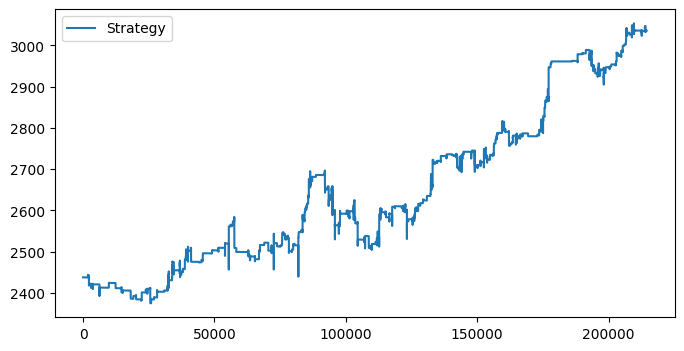

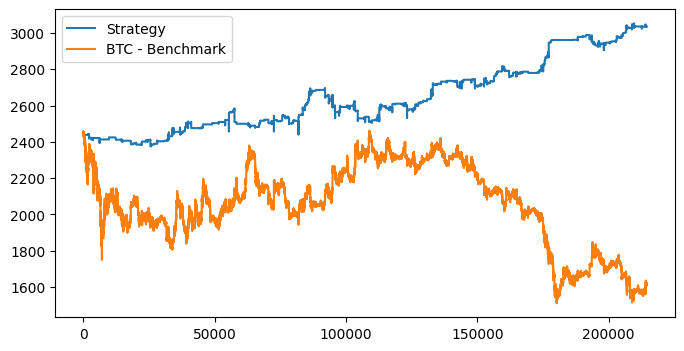

In [20]:
fee = 0.0001

df_bt = df_test.copy()


#Simple backtest routine

def BT(df_bt, fee):
    prev = df_bt.copy()
    
    ## Broker fee calculation
    broker_fee = (abs(prev['signals'])*df_bt['Avg']).sum()*(fee)
    prev['resu'] = -prev["signals"]*prev['Avg']
    df_bt.reset_index(drop=True, inplace=True)
    n = len(df_bt)-1
    
    ## Return of benchmarket for the whole period
    bench = (df_bt['Avg'][n]/df_bt['Avg'][0]-1)*100
    print('Benchmark return %', bench)
    
    
    port = (prev['resu'].sum()+df_bt['Avg'][0]-fee)/df_bt['Close'][0]-1
    
    #print('Portfolio', port*100)
    # Calculation of % change and daily return
    df_bt['Change'] = df_bt['Avg'].diff()
    df_bt['Change'][0] = 0
    df_bt['fee'] = fee * abs(df_bt['signals'])*df_bt['Avg']
    df_bt['PNL'] = df_bt['Change']*df_bt['pos'] - df_bt['fee']
    df_bt['PCT'] = df_bt['PNL']/df_bt['Avg']
    
    #Volatility calculation
    vol = df_bt['PCT'].std()
    n = len(df_bt)
    anual = vol*(365*60*24)**0.5
    print('Volatility', vol*100)
    print('Annualized vol', anual*100)
    
    # Daily ups and downs
    periods = len(df_bt)
    up = len(df_bt['PNL'][df_bt['PNL']>0])
    do = len(df_bt['PNL'][df_bt['PNL']<0])
    
    
    # Return calculation on the period and annualized
    retu = (df_bt['Open'][0] + df_bt['PNL'].sum())/df_bt['Avg'][0] - 1
    print('Return of the period %:', retu*100)
    days = periods/(60*24)
    annu =(retu +1)**(365/days)-1
    print('Return annual %:', annu*100)
    
    
    #Sharpe calculation, 
    print('Sharpe:', (annu*100)/(anual*100))
    df_bt['day'] = df_bt['PNL'].rolling(1440).sum()
    
    #Maximun and minimum daily return
    maxi = df_bt['day'].max()
    loc_max = df_bt['day'].idxmax()
    cl_max = df_bt['Avg'][loc_max]
    mini = df_bt['day'].min()
    loc_min = df_bt['day'].idxmin()
    cl_min = df_bt['Avg'][loc_min]
    
    
    #Total number of signals
    tot_sig = abs(df_bt['signals']).sum()
    print('total signals:', tot_sig)
    print('Max 24 hrs return', maxi/cl_max*100)
    print('Max 24 hrs drawdown', mini/cl_min*100)
    
    #AVG, MAX Holding period

    df_bt['Any_pos'] = df_bt['pos'].apply(lambda x: 1 if x==0 else 0)

    df_bt['gap'] = (df_bt.groupby(['Any_pos','Any_pos', df_bt['Any_pos'].cumsum()])
             ['Any_pos'].transform('size')
             .where(df_bt['Any_pos'].eq(0), other=0)
            )

    up_n = np.count_nonzero(df_bt['gap'])
    avg_up = df_bt['gap'].sum()/up_n
    max_up = df_bt['gap'].max()

    i1, d1 = divmod(avg_up/60, 1)
    i2, d2 = divmod(max_up/60, 1)

    print("Average holding period:", i1,' hours ',d1*60,' minutes' )
    print("Max holding period :", i2,' hours ',d2*60,' minutes')
    df_bt['PNL_cum'] = df_bt['PNL']
    df_bt['PNL_cum'][0] = df_bt['Open'][0]
    df_bt['PNL_cum'] = df_bt['PNL_cum'].cumsum()



    
    plt.figure(figsize=(8,4))
    plt.plot(df_bt['PNL_cum'], label = 'Strategy')

    plt.legend()
    

    plt.figure(figsize=(8,4))
    plt.plot(df_bt['PNL_cum'], label = 'Strategy')
    plt.plot(df_bt['Avg'], label = 'BTC - Benchmark')
    plt.legend()

BT(df_bt, fee)


In [21]:
def get_poc_fast(indices, df_full, bins=20):
        n = len(close)
        out = np.full(n, np.nan)

        # Start calculation after reaching min_periods (70)
        for i in range(min_periods - 1, n):
            # Logic for exoansive windowa:
            # If i < 300, window =  [0 : i+1] (size i+1)
            # If i >= 300, window =  [i-299 : i+1] (size 300)
            start = max(0, i - max_window + 1)

            w_close = close[start : i + 1]
            w_vol = volume[start : i + 1]

            p_min = np.min(w_close)
            p_max = np.max(w_close)

            if p_min >= p_max:
                out[i] = 0.0
                continue

            # Histogram manual (Optimized for Numba)
            hist = np.zeros(bins)
            bin_width = (p_max - p_min) / bins

            for j in range(len(w_close)):
                # Calculate bin 
                val = w_close[j]
                idx = int((val - p_min) / bin_width)
                if idx >= bins: 
                    idx = bins - 1 # min value for the last bin
                hist[idx] += w_vol[j]

            # Find bin with higher volume (Point of Control)
            max_bin_idx = np.argmax(hist)
            poc = p_min + (max_bin_idx + 0.5) * bin_width

            # p_last / poc - 1 (deviation of volume avg price)
            out[i] = close[i] / poc - 1

        return out

        # Calling function
        df['Vpro'] = fast_poc_expanding_numba(
            df['close'].values, 
            df['volume'].values, 
            max_window=300, 
            min_periods=70
        )

        return df


def ARO2(df):
    
    @njit
    def fast_aroon_osc(high, low, window):
        n = len(high)
        out = np.full(n, np.nan)

        for i in range(window - 1, n):
            max_idx = 0
            min_idx = 0
            max_val = high[i - window + 1]
            min_val = low[i - window + 1]

            for j in range(1, window):
                curr_h = high[i - window + 1 + j]
                curr_l = low[i - window + 1 + j]

                if curr_h >= max_val:
                    max_val = curr_h
                    max_idx = j
                if curr_l <= min_val:
                    min_val = curr_l
                    min_idx = j

            days_since_max = (window - 1) - max_idx
            days_since_min = (window - 1) - min_idx

            up = ((window - days_since_max) / window) * 100
            down = ((window - days_since_min) / window) * 100
            
            out[i] = up - down
            
        return out

    # Direct extraction and single function execution for window = 15
    df['AAR_15'] = fast_aroon_osc(df['high'].values, df['low'].values, 15)
    
    return df



###### Weighted MACD short term ######


@nb.njit(cache=True)
def ewm_numba(arr, span):
    """Calculates Exponential Moving Average matching Pandas 'adjust=False'."""
    n = len(arr)
    out = np.empty(n, dtype=np.float64) # 🟢 FIXED: Allocates a clean, isolated array in memory
    if n == 0:
        return out

    alpha = 2.0 / (span + 1.0)

    # Safely prime the first valid element
    if n > 0:
        out[0] = arr[0]

    for i in range(1, n):
        if np.isnan(arr[i]):
            out[i] = out[i-1]
        elif np.isnan(out[i-1]):
            out[i] = arr[i]
        else:
            out[i] = arr[i] * alpha + out[i-1] * (1.0 - alpha)
    return out

@nb.njit(cache=True)
def rolling_mean_numba(arr, window):
    """Calculates standard Simple Moving Average (SMA)."""
    n = len(arr)
    out = np.empty(n)
    out[:] = np.nan

    if n < window:
        return out

    current_sum = 0.0
    for i in range(window):
        current_sum += arr[i]
    out[window - 1] = current_sum / window

    for i in range(window, n):
        current_sum += arr[i] - arr[i - window]
        out[i] = current_sum / window
    return out

@nb.njit(parallel=True, cache=True)
def process_signals_numba(close,n1, n2, n3):
    """Processes MACD EWM/Rolling layers and handles vectorized signal logic."""
    n = len(close)

    # --- 1. EXPONENTIAL MACD LAYER (EWM) ---
    ma_fast_ewm = ewm_numba(close, n1)
    ma_slow_ewm = ewm_numba(close, n2)
    ma_ewm = ma_fast_ewm - ma_slow_ewm
    sig_ewm = ewm_numba(ma_ewm, n3)
    macds_ewm = ma_ewm - sig_ewm
    macd_out = np.zeros(n)

    # --- 2. ROLLING MACD LAYER (SMA) ---
    ma_fast_roll = rolling_mean_numba(close, n1)
    ma_slow_roll = rolling_mean_numba(close, n2)
    ma_roll = ma_fast_roll - ma_slow_roll
    sig_roll = ewm_numba(ma_roll, n3)
    macds_roll = ma_roll - sig_roll
    macdn_out = np.zeros(n)

    
    return macd_out, ma_ewm

# --- 2. MAIN INTEGRATION WRAPPER FOR PANDAS DATAFRAMES ---

def execute_strategy_numba(df):
    """Extracts NumPy arrays from DataFrame, triggers Numba, and commits back."""
    close = np.ascontiguousarray(df['close'].to_numpy(dtype=np.float64))
    low = np.ascontiguousarray(df['low'].to_numpy(dtype=np.float64))
    high = np.ascontiguousarray(df['high'].to_numpy(dtype=np.float64))
    volume = np.ascontiguousarray(df['volume'].to_numpy(dtype=np.float64))


    # Step 2: Unified loop execution
    for i in range(12, 25, 6):
        n1, n2, n3 = i, 2 * i, int(round(i / 1.5)) # 🟢 OPTIMIZED: Forces explicit int signature to ensure clean compilation

        macd_out, ma_ewm = process_signals_numba(
            close, n1, n2, n3
        )

        #df[f'MACD_{i}'] = macd_out
        df[f'MA_{i}'] = ma_ewm
        #df[f'MACDS_{i}'] = macds_ewm
        #df[f'MACDN_{i}'] = macdn_out

    return df
def WMA2(df):
    # Execute the strategy using your DataFrame
    df = execute_strategy_numba(df)
    return df





#@njit
def fast_vwap_zscore(close, high, low, volume, max_window=300, min_periods=30):
    n = len(close)
    vwap_z = np.full(n, np.nan)

    # Tipical price weighted by volume: (H+L+C)/3 * Vol
    tp_vol = ((close + high + low) / 3.0) * volume

    for i in range(min_periods - 1, n):
        # Define beginning of the window (expansive to max_window)
        start = max(0, i - max_window + 1)

        # Add to VWAP
        sum_tp_vol = np.sum(tp_vol[start : i + 1])
        sum_vol = np.sum(volume[start : i + 1])

        if sum_vol == 0:
            vwap_z[i] = 0.0
            continue

        current_vwap = sum_tp_vol / sum_vol

        # Z-Score (df['Close'] - vwap) / std(vwap)
        
        if i >= start + min_periods:
            # Calculate STD for values of VWAP on the window
            # Extract histórical VWAPs parcials
            window_vwaps = np.zeros(i - start + 1)
            temp_tp_vol = 0.0
            temp_vol = 0.0

            # Sub-loop calculate histórical VWAPs for STD
            for k in range(start, i + 1):
                temp_tp_vol = np.sum(tp_vol[start : k + 1])
                temp_vol = np.sum(volume[start : k + 1])
                window_vwaps[k - start] = temp_tp_vol / temp_vol if temp_vol != 0 else current_vwap

            std_vwap = np.std(window_vwaps)

            if std_vwap != 0:
                vwap_z[i] = (close[i] - current_vwap) / std_vwap
            else:
                vwap_z[i] = 0.0

    return vwap_z

def VWAP2(df):
    # Calling DataFrame
    df['VWAP_i'] = fast_vwap_zscore(
        df['close'].values, df['high'].values, 
        df['low'].values, df['volume'].values
    ) 
    
        
    return df



def CCI2(df):

    #@njit
    def calcular_cci_fast(typ_price, window):
        n = len(typ_price)
        out = np.full(n, np.nan)

        for i in range(window - 1, n):
            # 1. Select window Tipical Price
            janela = typ_price[i - window + 1 : i + 1]

            # 2. MA Tipical price (TP_MA)
            tp_ma = np.mean(janela)

            # 3.Absolute Deviation (MAD) 
            # 
            mad = np.mean(np.abs(janela - tp_ma))

            # 4. Cálculate do CCI
            if mad != 0:
                out[i] = (typ_price[i] - tp_ma) / (0.015 * mad)
            else:
                out[i] = 0

        return out

    # Integration on the Loop
    tp = ((df['high'] + df['low'] + df['close']) / 3).values

    i = 10
    df[f'CCI_{i}'] = calcular_cci_fast(tp, i)

    return df



#@njit
def calcular_atr_wilder(high, low, close, window):
    n = len(high)
    tr = np.zeros(n)
    atr = np.zeros(n)

    # 1. Cálculate True Range (TR)
    for i in range(1, n):
        hl = high[i] - low[i]
        hc = abs(high[i] - close[i-1])
        lc = abs(low[i] - close[i-1])
        tr[i] = max(hl, max(hc, lc))
    tr[0] = high[0] - low[0] # first value

    # 2. Cálculate ATR (Softness Wilder)
    # First ATR is the average of first 'window' TRs
    sum_tr = 0.0
    for i in range(window):
        sum_tr += tr[i]
    atr[window-1] = sum_tr / window

    # Next ATRs: (ATR_anterior * (n-1) + TR_atual) / n
    for i in range(window, n):
        atr[i] = (atr[i-1] * (window - 1) + tr[i]) / window

    return atr

def ATR2(df):
    # Extract arrays
    h = df['high'].values
    l = df['low'].values
    c = df['close'].values

    i = 7
    atr_values = calcular_atr_wilder(h, l, c, i)
    df[f'ATR_{i}'] = atr_values / c
    
    return df



def RSI2(df):
    df['S1_pct'] = df['close'].pct_change()

    #@njit
    def calcular_rsi_wilder(changes, window):
        n = len(changes)
        rsi = np.full(n, np.nan)

        # Separate gains and losses (Vetorization Numba)
        gains = np.where(changes > 0, changes, 0.0)
        losses = np.where(changes < 0, -changes, 0.0)

        # Inicialization (Simple avg for the first value)
        avg_gain = np.mean(gains[:window])
        avg_loss = np.mean(losses[:window])

        if avg_loss == 0:
            rsi[window-1] = 100
        else:
            rs = avg_gain / (avg_loss + 1e-10)
            rsi[window-1] = 100 - (100 / (1 + rs))

        # Wilder softness (Recursive)
        for i in range(window, n):
            avg_gain = (avg_gain * (window - 1) + gains[i]) / window
            avg_loss = (avg_loss * (window - 1) + losses[i]) / window

            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / (avg_loss + 1e-10)
                rsi[i] = 100 - (100 / (1 + rs))

        return rsi - 50 # Retorna centralizado no 0 conforme seu código

    # Loop integration
    # S1_pct pct change of Close
    changes = df['S1_pct'].values

    for i in range(10, 11, 10):
        df[f'RSI_{i}'] = calcular_rsi_wilder(changes, i)
        
    #df = df.dropna()
    #df = df.reset_index(drop=True)
        
    return df



def HA2(df):

    #@njit # Just-In-Time compilation for max performance 
    def calcular_ha_core(op, hi, lo, cl):
        n = len(op)
        ha_open = np.empty(n)
        ha_close = (op + hi + lo + cl) / 4.0

        # First candle (Seed)
        ha_open[0] = (op[0] + cl[0]) / 2.0

        # Loop recursive 
        for i in range(1, n):
            ha_open[i] = (ha_open[i-1] + ha_close[i-1]) / 2.0

        # High and low
        ha_high = np.maximum(hi, np.maximum(ha_open, ha_close))
        ha_low = np.minimum(lo, np.minimum(ha_open, ha_close))

        # Vetorization of signals (1 for up, -1 for down, 0 neutral)
        sinal = np.zeros(n)
        for i in range(n):
            if (ha_close[i] > ha_open[i]) and (ha_open[i]==ha_low[i]):
                sinal[i] = 1.0
            elif (ha_close[i] > ha_open[i]) and (ha_close[i-1] < ha_open[i]):
                sinal[i] = 1.0
            
            elif (ha_close[i] < ha_open[i]) and (ha_open[i]==ha_high[i]):
                sinal[i] = -1.0  
            elif (ha_close[i] < ha_open[i]) and (ha_close[i-1] > ha_open[i]):
                sinal[i] = -1.0

        return sinal

    def sequence_counter(sinal):
        # Lógic to count sequence (Reset on 0)
        # Convert to NumPy to avoid overhead groups Pandas
        n = len(sinal)
        ha_count = np.zeros(n)
        current_sum = 0.0

        for i in range(n):
            if sinal[i] == 0:
                current_sum = 0.0
            elif i > 0 and sinal[i] != sinal[i-1]:
                current_sum = sinal[i] # Reset e começa nova contagem
            else:
                current_sum += sinal[i]
            ha_count[i] = current_sum
        return ha_count

    # Integration on DataFrame
    df['HA_Sinal'] = calcular_ha_core(df['open'].values, df['high'].values, 
                                      df['low'].values, df['close'].values)

    df['HA_Seq'] = sequence_counter(df['HA_Sinal'].values)
        
        
    return df

def TGT(df, hold_pos=hold_pos):
    # 1. Cálcultion of Return (Past Based to avoid Look-ahead)
    target_price = df['avg'].ewm(span=int(hold_pos), adjust=False).mean()
    
    #  .values to avoid problems memory Pandas
    avg_values = df['avg'].values
    avg_shifted = df['avg'].shift(hold_pos).values
    
    df["ret"] = (target_price.values / avg_shifted) - 1
    del target_price # cleaning

    
    # 
    df['Trig'] = df['ret'].abs().rolling(5).mean().shift(1)
    
    return df



In [ ]:
# ==============================================================================
# STEP 1: PRE-EMPTIVE CLEANUP OF LINGERING MEMORY SOCKETS
# ==============================================================================
# If a 'ws' object exists from a previous crashed run, force-terminate it now
if 'ws' in globals():
    try:
        print("Wiping old lingering WebSocket connection from memory...")
        ws.close()
        del ws
    except Exception:
        pass

# ==============================================================================
# STEP 2: BLINDED LIFECYCLE WRAPPER
# ==============================================================================
def start_pipeline_stream():
    global ws
    try:
        print("Initializing clean WebSocket connection tunnel...")
        
        # PLACE YOUR ORIGINAL WEBSOCKET LAUNCH LINE HERE. For example:
        # ws = websocket.WebSocketApp("wss://://binance.com", ...)
        # ws.run_forever()
        
    except KeyboardInterrupt:
        print("\nPipeline execution stopped manually by user.")
    except Exception as e:
        print(f"Critical Pipeline Execution Crash: {str(e)}")
    finally:
        # The finally block GUARANTEES that even if your ATR or Keras code explodes,
        # the network tunnel is unlinked, allowing immediate cell re-runs.
        print("Executing emergency resource cleanup. Unlinking network sockets...")
        try:
            ws.close()
        except NameError:
            pass
        print("Success: System state restored. Ready for re-run without kernel restart!")

# Launch the secure stream
start_pipeline_stream()








# ==========================================
# 1. LIVE DATA STATE CONTAINER
# ==========================================
class TradingState:
    def __init__(self):
        # Raw tick stream accumulator
        # Explicitly instantiating the dynamic state container
                
        self.df_acc = pd.DataFrame(columns=['symbol', 'open', 'high', 'low', 'close', 'volume', 't'])
        self.df_acc.index.name = 'timestamp'
        
        # Predefined structural schema to prevent KeyError 'Open'
        self.df_final = pd.DataFrame(columns=['symbol', 'open', 'high', 'low', 'close', 'volume', 'avg',
                                             'my_p', 'sig1', 'sig2', 'pnl', 'fee', 'real_re', 'trade_pr',
                                              'pos_count'])
        
        self.df_final.index.name = 'timestamp'
        
        
        self.df_final_lim = pd.DataFrame()
        self.count = 0  # Global execution tick counter
        self.next_sig = "zero" 
        self.realized_re = 0      
        self.ntrades = 0  
        

# Initialize the single global state object instance
state = TradingState()

# Initialize, load your saved weights safely, and evaluate
load_path = 'modelETHNumbaKFSwiGLU.pth'

model = SAMModel()
model.load_state_dict(torch.load(load_path, weights_only=True))
model.eval()

print(f'Model successfully loaded from {load_path} with matching architecture shapes!')




try:
    my_production_scaler = joblib.load('my_production_scaler_ETH_reg.pkl')
    #my_production_pca = joblib.load('my_production_pca_ETH.pkl')
    print("### Production Scaler successfully loaded into memory! ###", flush=True)
except FileNotFoundError:
    print("### ERROR: 'my_production_scaler.pkl' or PCA not found! Please export it from your training environment. ###", flush=True) 




def process_pipeline_sync(source_data):
    
    global state, model
    # HYPERPARAMETERS
    
    max_time = 25
    min_time = 3
    max_pos = 3

    up = 0.6 #0.4 #0.386
    up2 = 0
    do = -0.6 #-0.4 #-0.376
    do2 = 0
    mult_up = 3.95
    mult_do = 3.45

    k = 5 #2.5
    k_stop = -2 #-1.5
    hold_pos = 10
    #reference price
    price1 = 2492.76
    start_window = 100
    window = 8000
    l = window + 300
    
        
    try:
        payload = json.loads(source_data)
        
        # Unpack multiplexed stream packets instantly
        if 'data' in payload:
            payload = payload['data']
            
        # Early rejection of keep-alives or API metadata responses
        if 'result' in payload or ('id' in payload and 'k' not in payload):
            return

        if 'k' not in payload:
            return

        kline = payload['k']
        symbol = kline['s']
        open_p = float(kline['o'])
        high_p = float(kline['h'])
        low_p = float(kline['l'])
        close_p = float(kline['c'])
        volume = float(kline['v'])
        t_timestamp = kline['t']
        event_time = pd.to_datetime(payload.get('E', t_timestamp), unit='ms')

        # Build clean standalone tick frame slice
        tick_data = {
            'symbol': [str(symbol)], 'open': [open_p], 'high': [high_p],
            'low': [low_p], 'close': [close_p], 'volume': [volume], 't': [int(t_timestamp)]
        }
        df_tick = pd.DataFrame(tick_data, index=[event_time])
        df_tick.index.name = 'timestamp'
        
        # 1. ALWAYS feed the background streaming accumulator for temporal calculations (.diff/.shift)
        state.df_acc = pd.concat([state.df_acc, df_tick], ignore_index=False)

        # Enforce memory constraint boundaries
        if len(state.df_acc) > window:
            state.df_acc = state.df_acc.tail(window)

        # Filter operations to prioritize current asset target
        df_acc_1 = state.df_acc[state.df_acc['symbol'] == 'ETHUSDT'].copy()
        if df_acc_1.empty:
            return

        # 2. Feature engineering steps calculated on fast streaming arrays
        df_acc_1['dif'] = df_acc_1['t'].diff()
        df_acc_1['dif2'] = df_acc_1['dif'].shift(-1)
        
        if not df_acc_1.empty:
            df_acc_1.iat[0, df_acc_1.columns.get_loc('dif2')] = 0.0
            
        df_acc_1['avg'] = (df_acc_1['open'] + df_acc_1['close'] + df_acc_1['high'] + df_acc_1['low']) / 4.0
        
        # =================================================================
        # GATE FILTER: HALT PROCESSING UNTIL THE OFFICIAL 1M CANDLE CLOSES
        # =================================================================
        if not kline['x']:
            return

        state.count += 1
        candle_time = pd.to_datetime(df_acc_1.index[-1])
        
        # Clean stray non-datetime entries safely without resetting structural parameters
        if not state.df_final.empty:
            state.df_final.index = pd.to_datetime(state.df_final.index, errors='coerce')
            state.df_final = state.df_final[state.df_final.index.notna()]

        # Protect data feed from partial or missing index data during time rollover
        live_candle = df_acc_1.iloc[-1]
        if pd.isna(live_candle['open']) or pd.isna(live_candle['close']):
            data_source = df_acc_1.iloc[-2]
        else:
            data_source = live_candle

        # ==============================================================================
        # STABLE TIME-SERIES CONCATENATION (Preserves Column Primitives)
        # ==============================================================================
        candle_time_valid = pd.to_datetime(candle_time)

        # 1. Create a clean, single-row DataFrame with explicit float types
        new_candle_df = pd.DataFrame({
            'symbol': [str(data_source['symbol'])],
            'open': [float(data_source['open'])],
            'high': [float(data_source['high'])],
            'low': [float(data_source['low'])],
            'close': [float(data_source['close'])],
            'volume': [float(data_source['volume'])],
            'avg': [float(data_source['avg'])],
            'my_p': [0.0], 
            'sig1': [0.0],
            'sig2': [0.0], 'pnl': [0.0],
            'fee': [0.0], 'real_re': [0.0],
            'trade_pr': [0.0],
            'pos_count': [0.0]
        }, index=[candle_time_valid])
        new_candle_df.index.name = 'timestamp'
        
                   
            
        ####################################3    
                    
               
                
        if len(state.df_final)>=2:
            
            #Defibne the time for later in the code
            last_timestamp = state.df_final.index[-1]
            #last_timestamp = candle_time_valid
            
            if state.next_sig == 'long_1':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                trade_price_ref = state.df_final['avg'].at[last_timestamp]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = 1
                state.df_final.at[last_timestamp, 'my_p'] = 1
                state.df_final.at[last_timestamp, 'pos_count'] = 1
                state.df_final.at[last_timestamp, 'trade_pr'] = trade_price_ref

            elif state.next_sig == 'short_1':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                trade_price_ref = state.df_final['avg'].at[last_timestamp]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = -1
                state.df_final.at[last_timestamp, 'my_p'] = -1
                state.df_final.at[last_timestamp, 'pos_count'] = 1
                state.df_final.at[last_timestamp, 'trade_pr'] = trade_price_ref

            elif state.next_sig == 'long_2':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                trade_price_ref = state.df_final['avg'].at[last_timestamp]
                pos_ref = state.df_final['my_p'].ffill().iloc[-2]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = 1
                state.df_final.at[last_timestamp, 'my_p'] = int(pos_ref + 1)
                state.df_final.at[last_timestamp, 'pos_count'] = 1
                state.df_final.at[last_timestamp, 'trade_pr'] = trade_price_ref

            elif state.next_sig == 'close':     

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                trade_price_ref = state.df_final['avg'].at[last_timestamp]
                pos_ref = state.df_final['my_p'].ffill().iloc[-2]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = -pos_ref
                state.df_final.at[last_timestamp, 'my_p'] = 0
                state.df_final.at[last_timestamp, 'pos_count'] = 0
                state.df_final.at[last_timestamp, 'trade_pr'] = trade_price_ref



            elif state.next_sig == 'hold':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                count_ref = state.df_final['pos_count'].ffill().iloc[-2]
                pos_ref = state.df_final['my_p'].ffill().iloc[-2]
                #trade_price_ref = state.df_final['avg'].at[last_timestamp]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = 0
                state.df_final.at[last_timestamp, 'my_p'] = pos_ref 
                state.df_final.at[last_timestamp, 'pos_count'] = int(count_ref + 1)
                state.df_final.at[last_timestamp, 'trade_pr'] = 0 #trade_price_ref




            elif state.next_sig == 'short_2':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]

                # 2. Grab the reference price safely using the .at accessor
                trade_price_ref = state.df_final['avg'].at[last_timestamp]
                pos_ref = state.df_final['my_p'].ffill().iloc[-2]

                # 3. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = -1
                state.df_final.at[last_timestamp, 'my_p'] = int(pos_ref - 1)
                state.df_final.at[last_timestamp, 'pos_count'] = 1
                state.df_final.at[last_timestamp, 'trade_pr'] = trade_price_ref
            
            elif state.next_sig == 'zero':

                # 1. Capture the exact timestamp of the current active row
                #last_timestamp = state.df_final.index[-1]
                
                # 2. Atomically update the columns directly in the real DataFrame memory
                state.df_final.at[last_timestamp, 'sig1'] = 0
                state.df_final.at[last_timestamp, 'my_p'] = 0
                state.df_final.at[last_timestamp, 'pos_count'] = 0
                state.df_final.at[last_timestamp, 'trade_pr'] = 0
            

       
            
        
            
            
            
            
            
            
            
            
            
        
        # 2. Before merging, forcefully drop any duplicate columns that got stuck in memory
        if not state.df_final.empty:
            state.df_final = state.df_final.loc[:, ~state.df_final.columns.duplicated()].copy()

        # 3. Concatenate using explicit column filtering to force absolute alignment
        state.df_final = pd.concat([state.df_final, new_candle_df], axis=0, join='outer')

        # 4. HARD-DROP RECOVERY: Instantly purge any row that collapsed into NaN
        state.df_final = state.df_final.dropna(subset=['open', 'close', 'avg'])

        # ==============================================================================
        # POST-PROCESSING & PERFECT CHRONOLOGICAL ORDER
        # ==============================================================================
        state.df_final = state.df_final[~state.df_final.index.duplicated(keep='last')]
        state.df_final = state.df_final.sort_index()



        # Strictly enforce index naming
        state.df_final.index.name = 'timestamp'

        # Memory management protection for df_final
        if len(state.df_final) >window:
            state.df_final = state.df_final.tail(window)

        print(f"\n[CONFIRMED] CANDLE SAVED AT: {candle_time_valid} | Rows: {len(state.df_final)}")
        #print(state.df_final[['symbol', 'open', 'high', 'low', 'close']].tail(5))



        # 4. FIXED REFERENCE PRICE EXTRACTION (Eliminates the float ufunc log crash)
        # We extract the scalar raw float value directly from the very first row of 'open'
        #price1 = float(state.df_final['open'].head(0))

        # 5. Calculate cumulative percentage return column safely
        state.df_final['pct_return'] = ((state.df_final['close'].astype(float) - price1) / price1) * 100

        # Most indicators (ATR, RSI, CCI) require a minimum window lookback (usually 14 or 20 periods).
        # We skip indicator calculations until we accumulate enough historical 1m candles.
        MINIMUM_CANDLES_REQUIRED = 40





        if len(state.df_final) < MINIMUM_CANDLES_REQUIRED:
            print(f"\n[WARM-UP] Accumulating history: {len(state.df_final)}/{MINIMUM_CANDLES_REQUIRED} candles collected. Skipping math indicators...", flush=True)
            return

        # =================================================================
        # ####### ADVANCED MATHEMATICAL INDICATORS (INTEGRATED)
        # =================================================================
        data = state.df_final.copy()

        try:
            # CRITICAL NUMBA FIX: Force explicit primitive numeric casting on ALL core columns
            # This destroys the 'pyobject' wrapper, converting columns to clean native float64 arrays
            numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'avg']
            for col in numeric_cols:
                data[col] = pd.to_numeric(data[col], errors='coerce').astype(float)



            # Type casting to prevent internal numpy ufunc float validation errors
            data['avg'] = data['avg'].astype(float)
            data['Log'] = np.log(data['avg'])

            data = ARO2(data)
            data = CCI2(data)
            data = ATR2(data)
            data = WMA2(data)
            #data = RSI(data)
            data = VWAP2(data)
            data = HA2(data)
            data = TGT(data)
            #print (data[['MA_12', 'MA_24','ATR_7', 'VWAP_i', 'CCI_10', 'AAR_15', 'HA_Sinal']])
            # KALMAN filter execution mapping
            data = scan_dataframe_fast_dynamic(data, periods=10, q_lookback=60)
            data['M_R'] = data['market_regime'].apply(lambda x: 1 if x == "NON-STATIONARY" else 0)
            data['M_R_roll'] = data['M_R'].rolling(3).mean()
            
            #define reference price
            if len(data) <=100:
                    price1 = data['avg'].iloc[0]

            # CRITICAL FIX: Push the computed copy back into the global state container
            # This ensures that rolling formulas like .rolling(5) or indicators have historical data next minute
            state.df_final = data.copy()

            # Verify if the trigger column exists to prevent runtime KeyErrors
            if 'Trig' in data.columns:
                # Extract the trigger value as a pure scalar float
                trig = float(data['Trig'].iloc[-1])

                # FIX: Calculate nominal boundary values based on your exact multipliers
                # These variables are now ready to be compared with future percentage matrices
                pro_ = k * trig
                stop_ = k_stop * trig

            # =================================================================
            # ####### MEMORY OPTIMIZATION & RESOURCE MANAGEMENT
            # =================================================================
            # FIX: Maintain chronological data consistency by capping the rows to 300 
            # CRITICAL: Removed .reset_index() to preserve the datetime 'timestamp' index matrix.
            # Without the datetime index, rolling metrics and future lookups will crash.
            
            if len(data) > l:
                data = data.tail(l)
                
                
                
            # Sync the memory reduction slice back into the global state container
            state.df_final = data.copy()  

            # =================================================================
            # ####### FEATURE SELECTION VECTOR FOR ML INFERENCE (x_sig)
            # =================================================================
            # Ensure all required features exist in the columns to avoid runtime KeyErrors
            required_features = ['MA_12', 'MA_24','ATR_7', 'VWAP_i', 'CCI_10', 'AAR_15', 'HA_Sinal']

            # Dynamic safety check to verify if all selected indicators were successfully computed
            missing_features = [feat for feat in required_features if feat not in data.columns]

            if not missing_features:
                # Isolate the precise feature matrix slice for your machine learning model input
                x_sig = data[required_features].copy()


            if 'x_sig' in locals() and not x_sig.empty:
                try:
                    # =================================================================
                    # ####### PRODUCTION SCALING REUSE PIPELINE
                    # =================================================================
                    # Remove any boundary rows containing NaN values generated by indicator warm-ups
                    x_sig_clean = x_sig.dropna()


                    if not x_sig_clean.empty:
                        # REUSE: The loaded scaler applies the FIXED training mean and std instantly
                        X_sig_sc_array = my_production_scaler.transform(x_sig_clean)

                        # Reconstruct the array back into a temporary DataFrame to preserve column alignment
                        X_sig_sc = pd.DataFrame(X_sig_sc_array, columns=x_sig_clean.columns, index=x_sig_clean.index)

                        # Extract the single latest row vector as a clean NumPy 2D array (.values)
                        # This vector is 100% ready to be passed into your model.predict() function
                        latest_sample_ready = X_sig_sc.tail(1).values

                        print("\n[ML INFERENCE] Scaled feature matrix generated successfully using fixed parameters.", flush=True)
                        print(f"[ML INFERENCE] Clean Vector for Model Input:\n{latest_sample_ready}", flush=True)

                        # 2. REUSE PCA: Apply fixed principal components from training
                        #Transform() from the loaded object
                        #data_pca_array = my_production_pca.transform(X_sig_sc_array)
                        data_pca_array = X_sig_sc_array

                        # 3. RECONSTRUCT DATAFRAME: Preserve index timeline for ML tracking
                        data_pca = pd.DataFrame(
                            data_pca_array,
                            columns=['PC0', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6'],
                            index=x_sig_clean.index
                        )

                        #########################################################################

                        #print (data_pca)


                        if 'data_pca' in locals() and not data_pca.empty:

                            try:
                                # =================================================================
                                # ####### PRODUCTION KERAS INFERENCE PIPELINE
                                # =================================================================
                                latest_pca_vector = data_pca.values[-1:]

                                #latest_pca_vector = data_pca.values[-1:]
                                print ('latest_pca_vector ', latest_pca_vector )

                                # If your SAMModel expects a 3D sequential shape (batch, timesteps, features),
                                
                                # 1. Set the model to evaluation mode (safeguards BatchNorm/Dropout behaviors)
                                model.eval()
                                # 2. Extract raw data values if input is a Pandas DataFrame or standard array
                                #if hasattr(data_pca, 'values'):
                                #    data_pca_np = data_pca.values
                                #else:
                                #    data_pca_np = np.asarray(data_pca)

                                # 3. Convert input features into a clean float32 PyTorch tensor
                                data_tensor = torch.tensor(latest_pca_vector, dtype=torch.float32)

                                # 4. Automatically match the hardware device location of the model parameters (CPU/GPU)
                                model_device = next(model.parameters()).device
                                data_tensor = data_tensor.to(model_device)

                                # 5. Execute safe forward pass without computational graph overhead
                                with torch.no_grad():
                                    predictions = model(data_tensor).cpu().numpy().flatten()    
                                
                                # Sanitize target arrays by wiping data formatting variations
                                #actual_targets = y_test_sc.values.flatten() if hasattr(y_test_sc, 'values') else np.asarray(y_test_sc).flatten()
                                predicted_scores = predictions
                                #########################################################################################
                                
                                # Execute the prediction pass strictly on the active single row vector
                                y_pred_array = predictions
                                current_signal = float(y_pred_array[0])
                                print('current signal ', current_signal)


                                # Reconstruct into a tiny DataFrame using the current active candle timestamp
                                candle_time_valid = pd.to_datetime(candle_time)

                                #DIRECT SAVE: Write the prediction score directly into the permanent 'y_pred' column
                                state.df_final.loc[candle_time_valid, 'y_pred'] = current_signal
                                print(f"-> Prediction score saved in y_pred: {current_signal}")
                                print('Number of minutes for mean calculation: ',state.df_final['y_pred'].count())
                                
                                
                                if state.df_final['y_pred'].count()> start_window:
                                    mean_pred = state.df_final['y_pred'].mean()
                                    std_pred = state.df_final['y_pred'].std()
                                    up = mean_pred + (mult_up * std_pred)
                                    do = mean_pred - (mult_do * std_pred)
                                    
                                if state.df_final['y_pred'].count()>window:
                                    mean_pred = state.df_final['y_pred'].tail(window).mean()
                                    std_pred = state.df_final['y_pred'].tail(window).std()
                                    up = mean_pred + (mult_up * std_pred)
                                    do = mean_pred - (mult_do * std_pred)       
                                    
                                print('Current thresholds: ', do, up)
                                
                                
                                
                                
                                



                                #POSITION 

                                print('--- Strategy Metrics (Tail 5) ---')
                                # Use .tail(5) 
                                if 'my_p' in state.df_final.columns:
                                    print(state.df_final[['y_pred', 'my_p', 'sig1', 'sig2','pos_count','trade_pr']].tail(5), flush=True)

                                #Calculations
                                cl = float(data['close'].iloc[-1])
                                print('Last price recorded:', cl)

                                clav = float(data['avg'].iloc[-1])


                                #Calculate profit/loss from the last trade price
                                # Ensure the trade price history series is not empty
                                if not state.df_final['trade_pr'].empty and abs(int(state.df_final['my_p'].iloc[-1])) >= 1:


                                    # FIX 1: Use .ffill() to carry forward the original entry price from past minutes.
                                    # Reading .iloc[-1] directly would yield 0 or NaN since the new row just spawned.
                                    last_valid_entry_price = float(state.df_final['trade_pr'].ffill().iloc[-1])

                                    # Safety check to avoid division by zero crashes
                                    if last_valid_entry_price > 0:
                                        # Calculate the exact percentage return shift of the active open trade
                                        tr = (cl / last_valid_entry_price) - 1.0

                                        # Store the running return percentage into the current candle log row
                                        state.df_final.loc[last_timestamp, 'trade_return'] = float(tr)
                                        print(f"[RISK SYSTEM] Active trade return (tr): {tr * 100.0:.4f}%", flush=True)
                                    else:
                                        tr = 0.0
                                else:
                                    tr = 0.0
                                    state.df_final.loc[last_timestamp, 'trade_return'] = 0.0

                                ############# START TRADING RULES #####################

                                # 1. CHECK OPEN POSITION STATE: Equivalent to 'if my_p[-1] == 0:'
                                # Bypasses list appending arrays by tracking a single scalar engine pointer
                                # 1. FIX: Use np.isclose or mathematical tolerance to safely evaluate a float zero
                                #if state.df_final.at[last_timestamp, 'my_p'] == 0
                                if state.df_final['my_p'].iloc[-2] ==0:
                                #if np.isclose(float(state.df_final['my_p'].iloc[-1]), 0.0, atol=1e-5):

                                    # 2. EVALUATE STRATEGY CONDITIONAL BOUNDARIES (Using clean chained operators)
                                    if do < current_signal < up:

                                        print('No signal')


                                    # 3. OPEN LONG POSITION GATE (If score crosses the 'up' boundary AND market is stable)

                                    elif current_signal >= up and state.df_final['M_R_roll'].iloc[-1] != 1.0:

                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "long_1"
                                        state.next_sig = "long_1"
                                        print(f"Sinal LONG gravado com sucesso no candle atual!")




                                    # 3. OPEN SHORT POSITION GATE    
                                    elif current_signal <= do and state.df_final['M_R_roll'].iloc[-1] != 1.0:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "short_1"
                                        state.next_sig = "short_1"
                                        print(f"Sinal SHORT gravado com sucesso no candle atual!")

                                #elif state.df_final.at[last_timestamp, 'my_p'] >= 1:
                                elif state.df_final['my_p'].iloc[-2] >= 1:

                                    # 1st condition - add to position
                                    if current_signal >= up and state.df_final['my_p'].iloc[-2] < (max_pos) and state.df_final['M_R_roll'].iloc[-1] != 1.0:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "long_2"
                                        state.next_sig = "long_2"
                                        print(f"Sinal LONG gravado com sucesso no candle atual!")


                                    # 2nd condition - time-based close
                                    elif state.df_final['pos_count'].iloc[-2] >= max_time and current_signal < up:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig = "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")


                                    # 3rd condition - signal-based close
                                    elif current_signal <= do2 and state.df_final['pos_count'].iloc[-2] >= min_time:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig =  "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")


                                    # 4th condition - stop/profit
                                    elif tr <= stop_ or tr >= pro_:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig =  "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")

                                    # Hold position
                                    else:


                                        # Efind position for 'sig2' 
                                        #last_timestamp = state.df_final.index[-1]

                                        # fill directly last row
                                        # 2. Update 'sig2' directly using the label (Immune to the iloc bug)
                                        #state.df_final.at[last_timestamp, 'sig2'] = "hold"
                                        state.next_sig = "hold"
                                        print(f"Sinal HOLD gravado com sucesso no candle atual!")



                                #elif state.df_final.at[last_timestamp, 'my_p'] <= -1:
                                elif state.df_final['my_p'].iloc[-2]<= -1:

                                    # 1st condition - add to short
                                    if current_signal <= do and state.df_final['my_p'].iloc[-2] > (-max_pos) and state.df_final['M_R_roll'].iloc[-1] != 1.0:


                                        # Efind position for 'sig2' 
                                        #col_idx = state.df_final.columns.get_loc('sig2')

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "short_2"
                                        state.next_sig = "short_2"
                                        print(f"Sinal SHORT gravado com sucesso no candle atual!")



                                    # 2nd condition - time-based close
                                    elif state.df_final['pos_count'].iloc[-2] >= max_time and current_signal > do:


                                        ## find position for 'sig2' 
                                        #col_idx = state.df_final.columns.get_loc('sig2')

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig =  "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")


                                    # 3rd condition - signal-based close
                                    elif current_signal >= up2 and state.df_final['pos_count'].iloc[-2] >= min_time:


                                        # Efind position for 'sig2' 
                                        #col_idx = state.df_final.columns.get_loc('sig2')

                                        # fill directly last rowstate.
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig =  "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")


                                    # 4th condition - stop/profit
                                    elif -tr <= stop_ or -tr >= pro_:


                                        # Efind position for 'sig2' 
                                        #col_idx = state.df_final.columns.get_loc('sig2')

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "close"
                                        state.next_sig =  "close"
                                        print(f"Sinal CLOSE gravado com sucesso no candle atual!")


                                    # Hold position
                                    else:


                                        # Efind position for 'sig2' 
                                        #col_idx = state.df_final.columns.get_loc('sig2')

                                        # fill directly last row
                                        #state.df_final.at[last_timestamp, 'sig2'] = "hold"
                                        state.next_sig = "hold"
                                        print(f"Sinal HOLD gravado com sucesso no candle atual!")


                                print('##### next_sig#########', state.next_sig)

                                candle_time_valid = pd.to_datetime(candle_time)        
                                print('Last minute signal:', state.df_final.loc[candle_time_valid, 'sig1'] )


                                cl_avg = state.df_final.loc[candle_time_valid, 'avg']
                                pos_price = -state.df_final.loc[candle_time_valid, 'sig1'] * cl_avg 
                                
                                #extract last my_p
                                #last_my_p = state.df_final['my_p'].iloc[-2]

                                try:
                                    realized_re  # Try this variable
                                except NameError:
                                    realized_re = 0 
                                

                                ############ Printing results #####################

                                if state.df_final['my_p'].iloc[-2] == 0:
                                    state.df_final['fee'] = abs(state.df_final['sig1']*state.df_final['trade_pr']*0.0001)
                                    state.df_final['pnl'] = -(state.df_final['sig1']*state.df_final['trade_pr']) - state.df_final['fee'] 

                                    #print('accumulated pnl', state.df_final['pnl'].fillna(0).sum())
                                    pct_ret = (state.df_final['pnl'].fillna(0).sum()/price1)*100
                                    state.realized_re = pct_ret
                                    print('accumulated % return', state.realized_re)
                                    state.ntrades = int(state.df_final['sig1'].fillna(0).abs().sum())
                                    print('number pf trade', state.ntrades)

                                else:

                                    print('realized % return', state.realized_re)
                                    # Extract current active position layer level and max allowed scale cap
                                    current_p_level = int(state.df_final['my_p'].iloc[-2])
                                    #max_pos = 3.0  # Equivalent to your max_pos normalization multiplier constant
                                    cl = float(state.df_final['close'].iloc[-1])

                                    # Isolate all historical entries where an actual trade purchase was executed (price > 0)
                                    valid_entries = state.df_final[state.df_final['trade_pr'] > 0]['trade_pr']

                                    if not valid_entries.empty:
                                        # CASE 1: Position is scaled up to level 2 (Average of the last 2 valid entries)
                                        if abs(current_p_level) == 2 and len(valid_entries) >= 2:
                                            # FIX: Extract the last two unique historical execution prices via safe .iloc positionals
                                            # This bypasses the empty intermediate zeros that corrupted your original math
                                            adj_price = (float(valid_entries.iloc[-1]) + float(valid_entries.iloc[-2])) / 2.0

                                            # Standardized trade return calculation applying the exposure direction vector sign
                                            trade_pnl_pct = ((cl / adj_price) - 1.0) * 100.0 * (current_p_level)
                                            print(f"[RISK N2] Adjusted Entry Price: {adj_price:.5f} | Scaled Trade P&L: {trade_pnl_pct:.4f}%", flush=True)

                                        # CASE 2: Position is scaled up to maximum exposure level 3 (Average of last 3 valid entries)
                                        elif abs(current_p_level) == 3 and len(valid_entries) >= 3:
                                            # FIX: Extract the last three unique execution milestones securely
                                            adj_price = (float(valid_entries.iloc[-1]) + float(valid_entries.iloc[-2]) + float(valid_entries.iloc[-3])) / 3.0

                                            trade_pnl_pct = ((cl / adj_price) - 1.0) * 100.0 * (current_p_level)
                                            print(f"[RISK N3] Adjusted Entry Price: {adj_price:.5f} | Maximum Trade P&L: {trade_pnl_pct:.4f}%", flush=True)

                                        # CASE 3: Standard single position layer execution baseline (Level 1)
                                        else:
                                            # Safely fetch the single last valid historical buy marker via dynamic lookup
                                            last_single_entry = float(valid_entries.iloc[-1])
                                            trade_pnl_pct = ((cl / last_single_entry) - 1.0) * 100.0 * (current_p_level)
                                            print(f"[RISK N1] Base Entry Price: {last_single_entry:.5f} | Standard Trade P&L: {trade_pnl_pct:.4f}%", flush=True)

                                        # Persistent state integration mapping for future decision logs
                                        state.df_final.loc[candle_time, 'trade_return_pct'] = trade_pnl_pct
                                    else:
                                        print("[RISK SYSTEM] No valid execution trade entries detected in historical log matrix.", flush=True)







                            except Exception as keras_error:
                                print(f"\n[KERAS INFERENCE CRASH] Error during neural network forwarding pass: {keras_error}", flush=True)  










                        # --- EXECUTE PREDICTION ---
                        # prediction = my_ml_model.predict(latest_sample_ready)
                        # print(f"[ML INFERENCE] Prediction Signal: {prediction}", flush=True)

                    else:
                        print("\n[ML INFERENCE WARNING] x_sig is empty after dropping NaNs. Skipping scaling.", flush=True)

                except Exception as scaling_error:
                    print(f"\n[ML INFERENCE CRASH] Error during scaling pipeline execution: {scaling_error}", flush=True)
            else:
                print("\n[ML INFERENCE WARNING] x_sig is missing or empty. Skipping scaling pipeline.", flush=True)



            # PRINT CONTROL: Displays cleanly exactly once every 60 seconds
            print(f"\n=============================================", flush=True)
            print(f"   [CANDLE CLOSED] MINUTE ENTRY #{state.count}   ", flush=True)
            print(f"=============================================", flush=True)
            print(f"[INFO] Global baseline reference price (price1): {price1:.5f}", flush=True)
            print("\nCumulative Trading Matrix (df_final):", flush=True)
            #print(state.df_final.tail(5), flush=True)

        except NameError as e:
            print(f"\n[PIPELINE WARNING] Missing technical indicator definition: {e}", flush=True)
            print("Please declare all required indicator functions before initiating the stream.", flush=True)
            return


        #print("[PIPELINE] Reached here successfully:", flush=True)
        print(df_tick, flush=True)

    except Exception as pipeline_error:
        import traceback
        print(f"[PIPELINE CRASH] Error: {pipeline_error}", flush=True)
        traceback.print_exc(file=sys.stdout)
        sys.stdout.flush()


if __name__ == "__main__":
    # SOLUÇÃO DEFINITIVA: Usando o domínio de fallback global da Binance para Futuros (fapi)
    # Esse endpoint alternativo não aplica o bloqueio silencioso que congela a thread anterior
    FALLBACK_URL = "wss://stream.binance.com/ws/ethusdt@kline_1m"
    #FALLBACK_URL = "wss://fstream.binance.com/ws/DOGEUSDT@kline_1m"

    print(f"Connecting to Binance Fallback Endpoint: {FALLBACK_URL}", flush=True)

    while True:
        try:
            # Conexão direta via Socket persistente
            ws = websocket.create_connection(
                FALLBACK_URL, 
                timeout=10,
                suppress_origin=True # Ignora restrição de cabeçalho do Jupyter/Colab
            )
            print("### Connection successfully open and authenticated! ###", flush=True)
            print("Streaming data now...", flush=True)

            while True:
                # O script para aqui e ESPERA o pacote chegar. Se o servidor enviar, o print roda no mesmo instante
                message = ws.recv()
                process_pipeline_sync(message)





        except websocket.WebSocketTimeoutException:
            print("[WARNING] Connection timeout. Re-pinging server...", flush=True)
            continue
        except KeyboardInterrupt:
            print("\nClosing WebSocket connection...", flush=True)
            if 'ws' in locals(): ws.close()
            print("Disconnected.", flush=True)
            break
        except Exception as e:
            print(f"### Connection lost ({e}). Reconnecting in 5 seconds... ###", flush=True)
            time.sleep(5)

Wiping old lingering WebSocket connection from memory...
Initializing clean WebSocket connection tunnel...
Executing emergency resource cleanup. Unlinking network sockets...
Success: System state restored. Ready for re-run without kernel restart!
Model successfully loaded from modelETHNumbaKFSwiGLU.pth with matching architecture shapes!
### Production Scaler successfully loaded into memory! ###
Connecting to Binance Fallback Endpoint: wss://stream.binance.com/ws/ethusdt@kline_1m
### Connection successfully open and authenticated! ###
Streaming data now...

[CONFIRMED] CANDLE SAVED AT: 2026-10-05 22:28:00.058000 | Rows: 1

[WARM-UP] Accumulating history: 1/40 candles collected. Skipping math indicators...

[CONFIRMED] CANDLE SAVED AT: 2026-10-05 22:29:00.016000 | Rows: 2

[WARM-UP] Accumulating history: 2/40 candles collected. Skipping math indicators...

[CONFIRMED] CANDLE SAVED AT: 2026-10-05 22:30:00.028000 | Rows: 3

[WARM-UP] Accumulating history: 3/40 candles collected. Skipping m

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)




[CONFIRMED] CANDLE SAVED AT: 2026-10-06 11:18:00.024000 | Rows: 771

[ML INFERENCE] Scaled feature matrix generated successfully using fixed parameters.
[ML INFERENCE] Clean Vector for Model Input:
[[ 0.06620573  0.01527527 -0.77642564  0.33491825  1.19931497  0.66195912
   1.16384694]]
latest_pca_vector  [[ 0.06620573  0.01527527 -0.77642564  0.33491825  1.19931497  0.66195912
   1.16384694]]
current signal  -0.10153956711292267
-> Prediction score saved in y_pred: -0.10153956711292267
Number of minutes for mean calculation:  732
Current thresholds:  -0.42739690818804765 0.5444808419623466
--- Strategy Metrics (Tail 5) ---
                           y_pred  my_p  sig1  sig2  pos_count  trade_pr
timestamp                                                               
2026-10-06 11:14:00.025 -0.042905   0.0   0.0   0.0        0.0       0.0
2026-10-06 11:15:00.028 -0.050736   0.0   0.0   0.0        0.0       0.0
2026-10-06 11:16:00.017 -0.121129   0.0   0.0   0.0        0.0       0.0
20